# Example 2: Calm Water Resistance Using Speed-Resistance Curve

## Overview

This notebook demonstrates:
1. Creating a resistance model from speed-resistance data points
2. Interpolating resistance for any given speed
3. Interpolating speed for any given resistance
4. Understanding the difference between resistance and power
5. Deriving power from resistance and speed

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ship_model_lib.calm_water_resistance import CalmWaterResistanceBySpeedResistanceCurve

## Define Reference Data

Resistance typically follows a quadratic to cubic relationship with speed.

**Key Relationship:**
- Resistance: $R \propto V^2$ to $V^3$
- Power: $P = R \times V$

In [2]:
# Define reference speed-resistance points
speed_kn = np.array([2, 4, 6, 8, 10, 12, 14])
resistance_k_n = np.power(speed_kn, 2) * 3 / 1000  # Convert to kN

print("Reference Data Points:")
print(f"Speeds (kn):       {speed_kn}")
print(f"Resistance (kN):   {resistance_k_n}")

Reference Data Points:
Speeds (kn):       [ 2  4  6  8 10 12 14]
Resistance (kN):   [0.012 0.048 0.108 0.192 0.3   0.432 0.588]


## Create Resistance Model

In [3]:
resistance_model = CalmWaterResistanceBySpeedResistanceCurve(
    speed_ref_kn=speed_kn,
    resistance_ref_k_n=resistance_k_n
)

print("✓ Resistance model created successfully")

✓ Resistance model created successfully


## Example 1: Interpolate Resistance from Speed

In [4]:
test_speeds = np.array([3, 5, 7, 9, 11, 13])

print("Resistance Interpolation Results:")
print(f"{'Speed (kn)':>12} | {'Resistance (kN)':>16} | {'Extrapolated':>13}")
print("-" * 46)

for speed in test_speeds:
    resistance_result = resistance_model.get_resistance_from_speed(velocity_kn=speed)
    print(f"{speed:>12.2f} | {resistance_result.value:>16.3f} | {str(resistance_result.is_extrapolated):>13}")

Resistance Interpolation Results:
  Speed (kn) |  Resistance (kN) |  Extrapolated
----------------------------------------------
        3.00 |            0.027 |         False
        5.00 |            0.075 |         False
        7.00 |            0.147 |         False
        9.00 |            0.243 |         False
       11.00 |            0.363 |         False
       13.00 |            0.507 |         False


## Example 2: Interpolate Speed from Resistance

Inverse interpolation to find speed for given resistance values.

In [5]:
test_resistances = np.array([0.05, 0.1, 0.2, 0.3, 0.4, 0.5])

print("Speed Interpolation Results:")
print(f"{'Resistance (kN)':>16} | {'Speed (kn)':>12} | {'Extrapolated':>13}")
print("-" * 46)

for resistance in test_resistances:
    speed_result = resistance_model.get_speed_from_resistance(resistance_k_n=resistance)
    print(f"{resistance:>16.3f} | {speed_result.value:>12.2f} | {str(speed_result.is_extrapolated):>13}")

Speed Interpolation Results:
 Resistance (kN) |   Speed (kn) |  Extrapolated
----------------------------------------------
           0.050 |         4.08 |         False
           0.100 |         5.77 |         False
           0.200 |         8.16 |         False
           0.300 |        10.00 |         False
           0.400 |        11.55 |         False
           0.500 |        12.91 |         False


## Example 3: Calculate Power from Resistance and Speed

**Power Calculation:**

$$P = R \times V$$

Where:
- $P$ = Power (kW)
- $R$ = Resistance (kN = 1000 N)
- $V$ = Speed (m/s)

**Unit Conversion:** 1 knot = 0.514444 m/s

In [6]:
print("Power Calculation from Resistance and Speed:")
print(f"{'Speed (kn)':>12} | {'Resistance (kN)':>16} | {'Power (kW)':>12}")
print("-" * 45)

for speed in test_speeds:
    resistance_result = resistance_model.get_resistance_from_speed(velocity_kn=speed)
    # Convert speed to m/s: 1 knot = 0.514444 m/s
    speed_ms = speed * 0.514444
    # Calculate power: P = R × V (where R is in kN, V in m/s, giving kW)
    power_kw = resistance_result.value * 1000 * speed_ms / 1000
    print(f"{speed:>12.2f} | {resistance_result.value:>16.3f} | {power_kw:>12.2f}")

Power Calculation from Resistance and Speed:
  Speed (kn) |  Resistance (kN) |   Power (kW)
---------------------------------------------
        3.00 |            0.027 |         0.04
        5.00 |            0.075 |         0.19
        7.00 |            0.147 |         0.53
        9.00 |            0.243 |         1.13
       11.00 |            0.363 |         2.05
       13.00 |            0.507 |         3.39


## Visualization

Create three plots:
1. Speed-Resistance Curve
2. Resistance-Speed Curve (Inverse)
3. Speed-Power Curve (Derived)


Visualization saved as 'example_02_speed_resistance_curve.png'


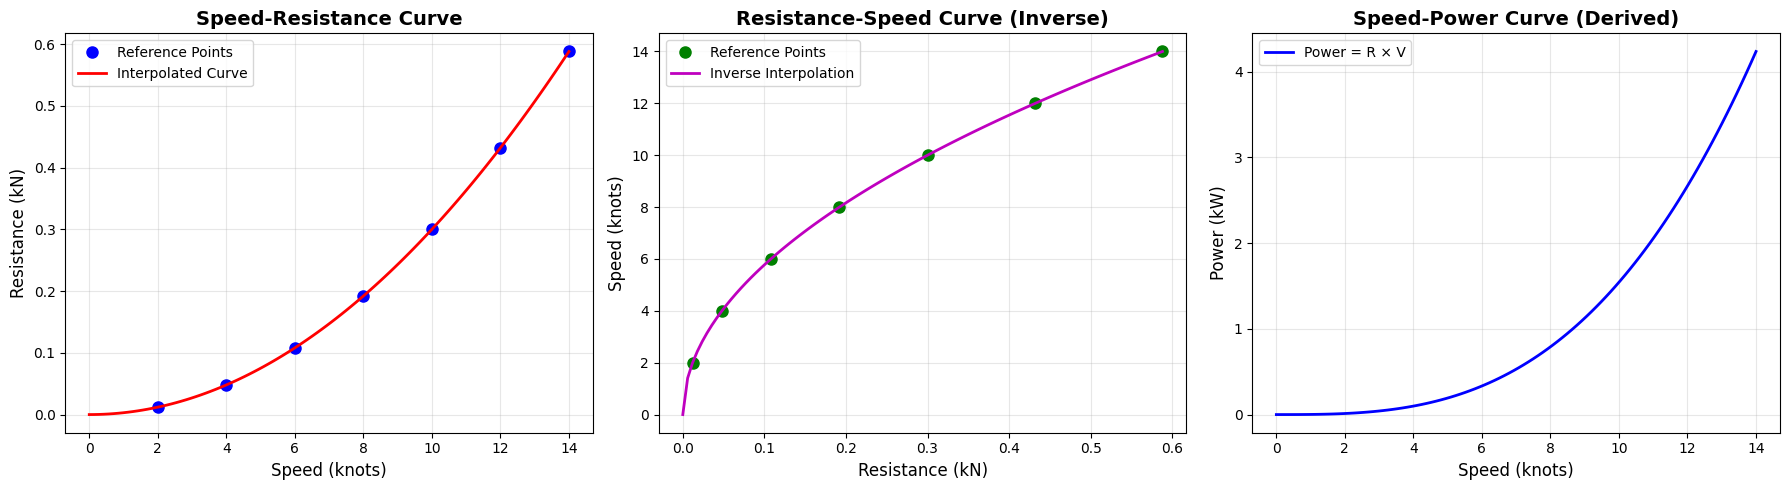

In [7]:
# Generate smooth curves
speed_smooth = np.linspace(0, speed_kn.max(), 100)
resistance_smooth = resistance_model.get_resistance_from_speed(velocity_kn=speed_smooth)

resistance_range = np.linspace(0, resistance_k_n.max(), 100)
speed_from_resistance = resistance_model.get_speed_from_resistance(resistance_k_n=resistance_range)

# Calculate power curve
speed_ms_smooth = speed_smooth * 0.514444
power_smooth = resistance_smooth.value * 1000 * speed_ms_smooth / 1000

# Create visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Speed vs Resistance
ax1.plot(speed_kn, resistance_k_n, 'bo', markersize=8, label='Reference Points')
ax1.plot(speed_smooth, resistance_smooth.value, 'r-', linewidth=2, label='Interpolated Curve')
ax1.set_xlabel('Speed (knots)', fontsize=12)
ax1.set_ylabel('Resistance (kN)', fontsize=12)
ax1.set_title('Speed-Resistance Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Resistance vs Speed (inverse interpolation)
ax2.plot(resistance_k_n, speed_kn, 'go', markersize=8, label='Reference Points')
ax2.plot(resistance_range, speed_from_resistance.value, 'm-', linewidth=2, label='Inverse Interpolation')
ax2.set_xlabel('Resistance (kN)', fontsize=12)
ax2.set_ylabel('Speed (knots)', fontsize=12)
ax2.set_title('Resistance-Speed Curve (Inverse)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Plot 3: Speed vs Power (derived from resistance)
ax3.plot(speed_smooth, power_smooth, 'b-', linewidth=2, label='Power = R × V')
ax3.set_xlabel('Speed (knots)', fontsize=12)
ax3.set_ylabel('Power (kW)', fontsize=12)
ax3.set_title('Speed-Power Curve (Derived)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=10)

plt.tight_layout()
plt.savefig('example_02_speed_resistance_curve.png', dpi=150, bbox_inches='tight')
print("\nVisualization saved as 'example_02_speed_resistance_curve.png'")
plt.show()

## Summary

This example demonstrated:
- ✓ Creating resistance model from speed-resistance data
- ✓ Forward interpolation (speed → resistance)
- ✓ Inverse interpolation (resistance → speed)
- ✓ Deriving power from resistance and speed
- ✓ Visualizing all three relationships

**Key Insights:**
- Resistance typically grows quadratically with speed
- Power grows cubically with speed (since $P = R \times V$)
- Both resistance and power models are interchangeable but serve different use cases